In [11]:
###  Dataset Overview
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
#check your notebook location
import os

print(os.getcwd())

C:\Users\Lenovo\Desktop\Mahak Project\Ecommerce-Sales-Profit-Analytics\python\notebooks


In [13]:
#load the all datasets
orders = pd.read_csv(
    "../../data/raw/olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    "../../data/raw/olist_order_items_dataset.csv"
)

customers = pd.read_csv(
    "../../data/raw/olist_customers_dataset.csv"
)
products=pd.read_csv(
    "../../data/raw/olist_products_dataset.csv"
)
payments=pd.read_csv(
    "../../data/raw/olist_order_payments_dataset.csv"
)
reviews=pd.read_csv(
    "../../data/raw/olist_order_reviews_dataset.csv"
)
sellers = pd.read_csv("../../data/raw/olist_sellers_dataset.csv")


In [18]:
datasets = [
    ('Orders', orders),
    ('Order Items', order_items),
    ('Customers', customers),
    ('Products', products),
    ('Payments', payments),
    ('Reviews', reviews)
]

summary_report = []

for name, df in datasets:

    summary_report.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'MissingValues': df.isna().sum().sum(),
        'DuplicateRows': df.duplicated().sum()
    })

summary_report = pd.DataFrame(summary_report)

summary_report

,Dataset,Rows,Columns,MissingValues,DuplicateRows
0,Orders,99441,10,4908,0
1,Order Items,112650,7,0,0
2,Customers,99441,5,0,0
3,Products,32951,9,2448,0
4,Payments,103886,5,0,0
5,Reviews,99224,7,145903,0


In [20]:
# =========================================================
# P7: Basic EDA KPIs
# =========================================================

# 1. Total Orders
print("Total Orders:", orders['order_id'].nunique())

# 2. Unique Customers
print(
    "Unique Customers:",
    customers['customer_unique_id'].nunique()
)

# 3. Total Products
print(
    "Total Products:",
    products['product_id'].nunique()
)

# 4. Total Sellers
print(
    "Total Sellers:",
    sellers['seller_id'].nunique()
)

# 5. Total Order Items
print(
    "Total Order Items:",
    len(order_items)
)

# 6. Order Date Range
purchase_dates = pd.to_datetime(
    orders['order_purchase_timestamp'],
    errors='coerce'
)

print(
    "Earliest Order:",
    purchase_dates.min()
)

print(
    "Latest Order:",
    purchase_dates.max()
)

Total Orders: 99441
Unique Customers: 96096
Total Products: 32951
Total Sellers: 3095
Total Order Items: 112650
Earliest Order: 2016-09-04 21:15:19
Latest Order: 2018-10-17 17:30:18


In [28]:
# =========================================================
# P8: Monthly Orders and Revenue Trend
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Convert purchase timestamp to datetime
# ---------------------------------------------------------

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'],
    errors='coerce'
)

# ---------------------------------------------------------
# 2. Extract Year and Month
# ---------------------------------------------------------

orders['Year'] = orders['order_purchase_timestamp'].dt.year
orders['Month'] = orders['order_purchase_timestamp'].dt.month

# ---------------------------------------------------------
# 3. Join orders with order items
# ---------------------------------------------------------

monthly_data = orders[
    ['order_id', 'Year', 'Month']
].merge(
    order_items[
        ['order_id', 'price']
    ],
    on='order_id',
    how='inner'
)

# ---------------------------------------------------------
# 4. Calculate monthly orders and revenue
# ---------------------------------------------------------

monthly_summary = (
    monthly_data
    .groupby(['Year', 'Month'])
    .agg(
        TotalOrders=('order_id', 'nunique'),
        TotalRevenue=('price', 'sum')
    )
    .reset_index()
)

# ---------------------------------------------------------
# 5. Sort chronologically
# ---------------------------------------------------------

monthly_summary = monthly_summary.sort_values(
    ['Year', 'Month']
)

monthly_summary

,Year,Month,TotalOrders,TotalRevenue
0,2016,9,3,267.36
1,2016,10,308,49507.66
2,2016,12,1,10.90
3,2017,1,789,120312.87
4,2017,2,1733,247303.02
5,2017,3,2641,374344.30
6,2017,4,2391,359927.23
7,2017,5,3660,506071.14
8,2017,6,3217,433038.60
9,2017,7,3969,498031.48


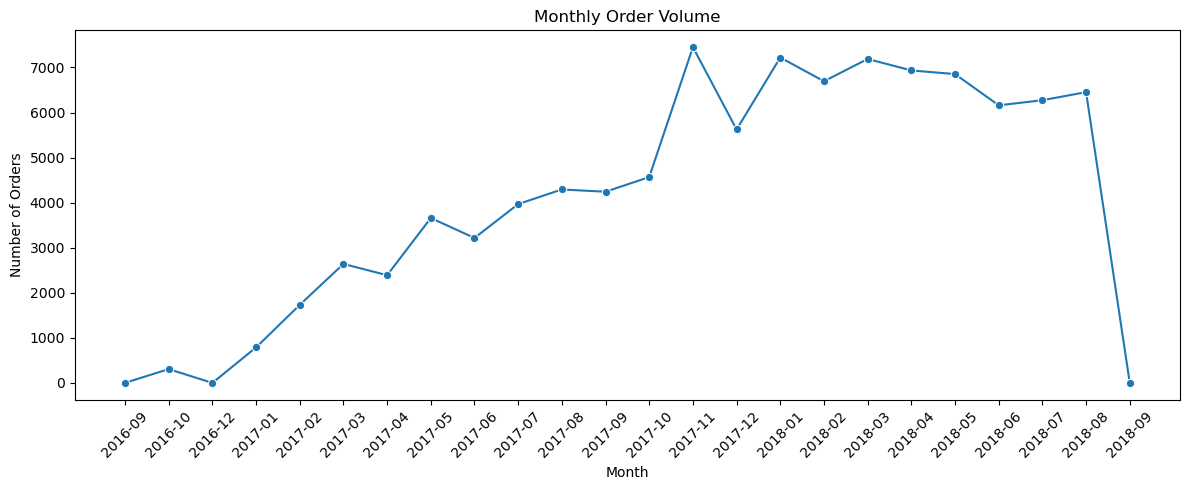

In [29]:
# =========================================================
# Chart 1: Monthly Order Volume
# =========================================================

monthly_summary['YearMonth'] = (
    monthly_summary['Year'].astype(str)
    + '-'
    + monthly_summary['Month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_summary,
    x='YearMonth',
    y='TotalOrders',
    marker='o'
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

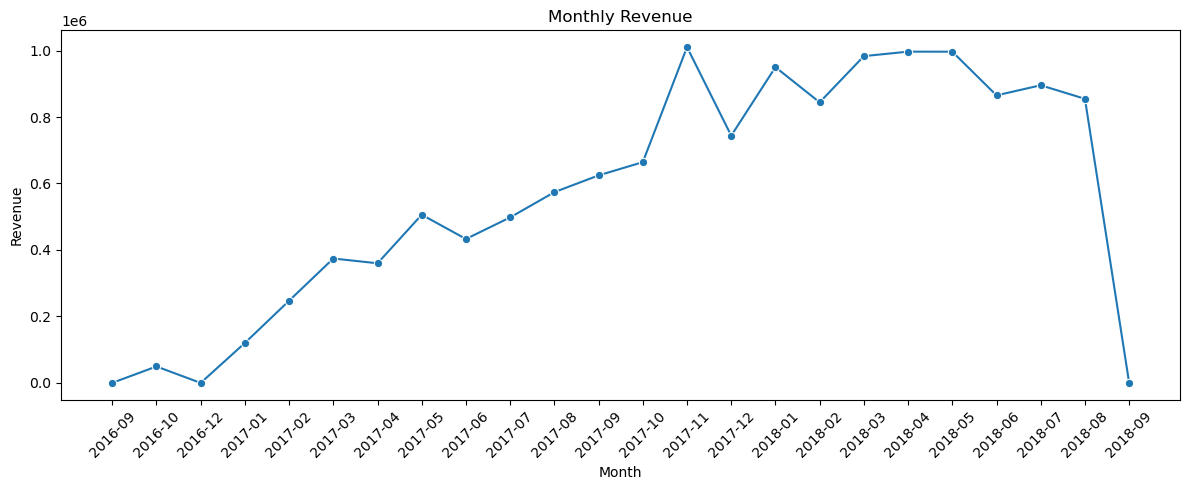

In [24]:
# =========================================================
# Chart 2: Monthly Revenue
# =========================================================

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_summary,
    x='YearMonth',
    y='TotalRevenue',
    marker='o'
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
monthly_summary.head(10)

,Year,Month,TotalOrders,TotalRevenue,YearMonth
0,2016,9,3,267.36,2016-09
1,2016,10,308,49507.66,2016-10
2,2016,12,1,10.90,2016-12
3,2017,1,789,120312.87,2017-01
4,2017,2,1733,247303.02,2017-02
5,2017,3,2641,374344.30,2017-03
6,2017,4,2391,359927.23,2017-04
7,2017,5,3660,506071.14,2017-05
8,2017,6,3217,433038.60,2017-06
9,2017,7,3969,498031.48,2017-07


In [1]:
# =========================================================
# P9: Revenue by Product Category
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv(
    "../../data/raw/olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    "../../data/raw/olist_order_items_dataset.csv"
)

products = pd.read_csv(
    "../../data/raw/olist_products_dataset.csv"
)

# IMPORTANT:
# This file is TAB-separated, not comma-separated.
translation = pd.read_csv(
    "../../data/raw/product_category_name_translation.csv",
    sep="\t"
)

print("Translation columns:")
print(translation.columns.tolist())

Translation columns:
['product_category_name', 'product_category_name_english']


In [2]:
## Confirm the translation column
translation_category_col = 'product_category_name'
translation_english_col = 'product_category_name_english'

print("Category column:", translation_category_col)
print("English category column:", translation_english_col)

Category column: product_category_name
English category column: product_category_name_english


In [3]:
# =========================================================
# Join order items with products
# =========================================================

category_data = order_items[
    ['product_id', 'price']
].merge(
    products[
        ['product_id', 'product_category_name']
    ],
    on='product_id',
    how='left'
)

print("Category data shape:", category_data.shape)

category_data.head()

Category data shape: (112650, 3)


,product_id,price,product_category_name
0,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff
1,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop
2,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao
3,7634da152a4610f1595efa32f14722fc,12.99,perfumaria
4,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim


In [4]:
# =========================================================
# Join with category translation
# =========================================================

category_data = category_data.merge(
    translation[
        [
            'product_category_name',
            'product_category_name_english'
        ]
    ],
    on='product_category_name',
    how='left'
)

print("After translation join:")

category_data.head()

After translation join:


,product_id,price,product_category_name,product_category_name_english
0,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff,cool_stuff
1,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop,pet_shop
2,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao,furniture_decor
3,7634da152a4610f1595efa32f14722fc,12.99,perfumaria,perfumery
4,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim,garden_tools


In [5]:
# =========================================================
# Create readable product category
# =========================================================

category_data['ProductCategory'] = (
    category_data['product_category_name_english']
    .fillna(category_data['product_category_name'])
    .fillna('Unknown')
)

category_data[
    [
        'product_category_name',
        'product_category_name_english',
        'ProductCategory'
    ]
].head(10)

,product_category_name,product_category_name_english,ProductCategory
0,cool_stuff,cool_stuff,cool_stuff
1,pet_shop,pet_shop,pet_shop
2,moveis_decoracao,furniture_decor,furniture_decor
3,perfumaria,perfumery,perfumery
4,ferramentas_jardim,garden_tools,garden_tools
5,utilidades_domesticas,housewares,housewares
6,telefonia,telephony,telephony
7,ferramentas_jardim,garden_tools,garden_tools
8,beleza_saude,health_beauty,health_beauty
9,livros_tecnicos,books_technical,books_technical


In [6]:
# =========================================================
# Calculate category-level metrics
# =========================================================

category_summary = (
    category_data
    .groupby('ProductCategory')
    .agg(
        TotalItemsSold=('product_id', 'count'),
        TotalRevenue=('price', 'sum'),
        AverageSellingPrice=('price', 'mean')
    )
    .reset_index()
)

category_summary['TotalRevenue'] = (
    category_summary['TotalRevenue'].round(2)
)

category_summary['AverageSellingPrice'] = (
    category_summary['AverageSellingPrice'].round(2)
)

category_summary = category_summary.sort_values(
    'TotalRevenue',
    ascending=False
)

category_summary.head(10)

,ProductCategory,TotalItemsSold,TotalRevenue,AverageSellingPrice
44,health_beauty,9670,1258681.34,130.16
73,watches_gifts,5991,1205005.68,201.14
8,bed_bath_table,11115,1036988.68,93.30
68,sports_leisure,8641,988048.97,114.34
16,computers_accessories,7827,911954.32,116.51
40,furniture_decor,8334,729762.49,87.56
21,cool_stuff,3796,635290.85,167.36
50,housewares,6964,632248.66,90.79
6,auto,4235,592720.11,139.96
43,garden_tools,4347,485256.46,111.63


In [7]:
# =========================================================
# Top 10 product categories by revenue
# =========================================================

top10_categories = category_summary.head(10)

top10_categories[
    [
        'ProductCategory',
        'TotalItemsSold',
        'TotalRevenue',
        'AverageSellingPrice'
    ]
]

,ProductCategory,TotalItemsSold,TotalRevenue,AverageSellingPrice
44,health_beauty,9670,1258681.34,130.16
73,watches_gifts,5991,1205005.68,201.14
8,bed_bath_table,11115,1036988.68,93.30
68,sports_leisure,8641,988048.97,114.34
16,computers_accessories,7827,911954.32,116.51
40,furniture_decor,8334,729762.49,87.56
21,cool_stuff,3796,635290.85,167.36
50,housewares,6964,632248.66,90.79
6,auto,4235,592720.11,139.96
43,garden_tools,4347,485256.46,111.63


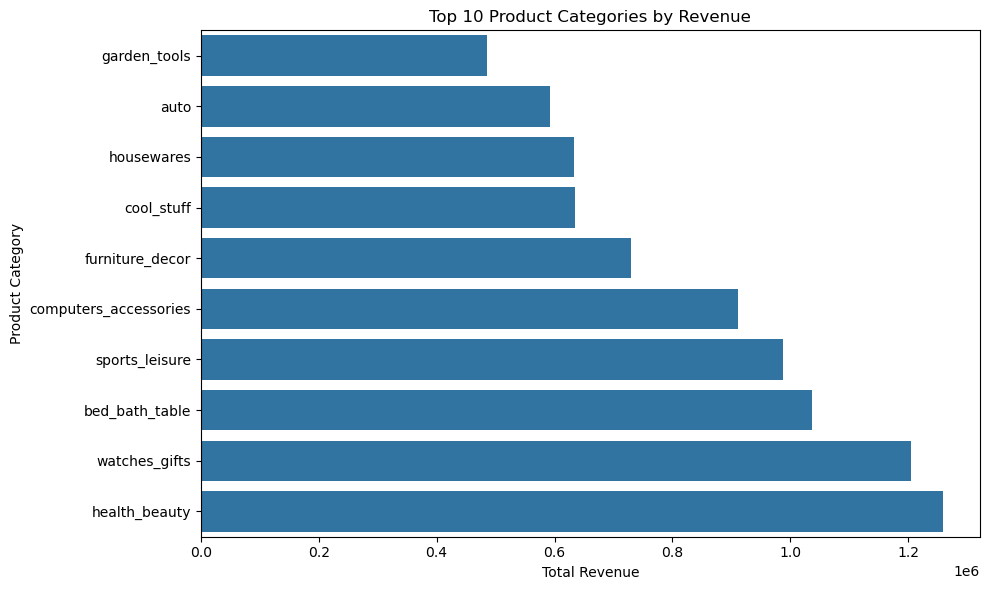

In [14]:
# =========================================================
# Top 10 Product Categories by Revenue
# =========================================================

plot_data = (
    top10_categories
    .sort_values(
        'TotalRevenue',
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x='TotalRevenue',
    y='ProductCategory'
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

In [15]:
# =========================================================
# Revenue concentration of the Top 10 categories
# =========================================================

top10_revenue = top10_categories['TotalRevenue'].sum()

total_revenue = category_summary['TotalRevenue'].sum()

top10_revenue_share = (
    top10_revenue * 100
    / total_revenue
)

print(
    f"Top 10 categories generate "
    f"{top10_revenue_share:.2f}% of total category revenue."
)

Top 10 categories generate 62.36% of total category revenue.


In [16]:
# =========================================================
# Final P9 output
# =========================================================

print("Top 10 Product Categories by Revenue:")

display(
    top10_categories[
        [
            'ProductCategory',
            'TotalItemsSold',
            'TotalRevenue',
            'AverageSellingPrice'
        ]
    ]
)

Top 10 Product Categories by Revenue:


,ProductCategory,TotalItemsSold,TotalRevenue,AverageSellingPrice
44,health_beauty,9670,1258681.34,130.16
73,watches_gifts,5991,1205005.68,201.14
8,bed_bath_table,11115,1036988.68,93.30
68,sports_leisure,8641,988048.97,114.34
16,computers_accessories,7827,911954.32,116.51
40,furniture_decor,8334,729762.49,87.56
21,cool_stuff,3796,635290.85,167.36
50,housewares,6964,632248.66,90.79
6,auto,4235,592720.11,139.96
43,garden_tools,4347,485256.46,111.63


In [ ]:
## Category Revenue Insights

The chart shows the product categories that contribute the most revenue.
The revenue concentration calculation helps determine whether overall sales are concentrated among a small number of categories or distributed more broadly.

In [9]:

# =========================================================
# P10: Monthly Revenue vs Order Volume
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Convert purchase timestamp to datetime
# ---------------------------------------------------------

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'],
    errors='coerce'
)

# ---------------------------------------------------------
# 2. Extract Year and Month
# ---------------------------------------------------------

orders['Year'] = orders['order_purchase_timestamp'].dt.year
orders['Month'] = orders['order_purchase_timestamp'].dt.month

# ---------------------------------------------------------
# 3. Merge orders with order items
# ---------------------------------------------------------

monthly_data = orders[
    ['order_id', 'Year', 'Month']
].merge(
    order_items[
        ['order_id', 'price']
    ],
    on='order_id',
    how='inner'
)

# ---------------------------------------------------------
# 4. Calculate monthly metrics
# ---------------------------------------------------------

monthly_summary = (
    monthly_data
    .groupby(['Year', 'Month'])
    .agg(
        TotalOrders=('order_id', 'nunique'),
        TotalRevenue=('price', 'sum')
    )
    .reset_index()
)

# ---------------------------------------------------------
# 5. Calculate Average Order Value
# ---------------------------------------------------------

monthly_summary['AverageOrderValue'] = (
    monthly_summary['TotalRevenue'] * 1.0
    / monthly_summary['TotalOrders']
)

# Round values
monthly_summary['TotalRevenue'] = (
    monthly_summary['TotalRevenue'].round(2)
)

monthly_summary['AverageOrderValue'] = (
    monthly_summary['AverageOrderValue'].round(2)
)

# ---------------------------------------------------------
# 6. Sort chronologically
# ---------------------------------------------------------

monthly_summary = monthly_summary.sort_values(
    ['Year', 'Month']
).reset_index(drop=True)

# Create a readable Year-Month label
monthly_summary['YearMonth'] = (
    monthly_summary['Year'].astype(str)
    + '-'
    + monthly_summary['Month'].astype(str).str.zfill(2)
)

# Display result
monthly_summary

,Year,Month,TotalOrders,TotalRevenue,AverageOrderValue,YearMonth
0,2016,9,3,267.36,89.12,2016-09
1,2016,10,308,49507.66,160.74,2016-10
2,2016,12,1,10.90,10.90,2016-12
3,2017,1,789,120312.87,152.49,2017-01
4,2017,2,1733,247303.02,142.70,2017-02
5,2017,3,2641,374344.30,141.74,2017-03
6,2017,4,2391,359927.23,150.53,2017-04
7,2017,5,3660,506071.14,138.27,2017-05
8,2017,6,3217,433038.60,134.61,2017-06
9,2017,7,3969,498031.48,125.48,2017-07


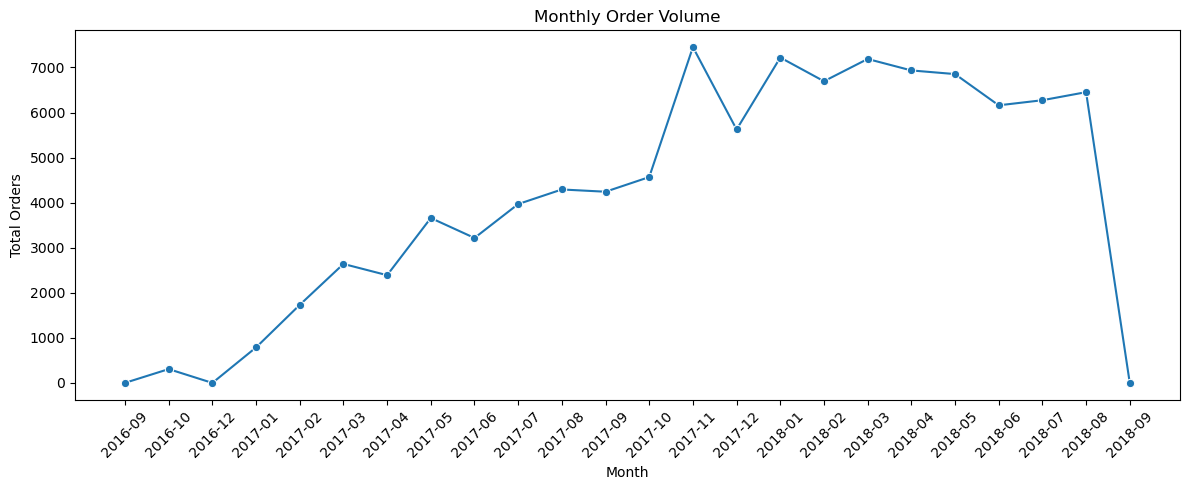

In [18]:
# =========================================================
# Chart 1: Monthly Order Volume
# =========================================================

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_summary,
    x='YearMonth',
    y='TotalOrders',
    marker='o'
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

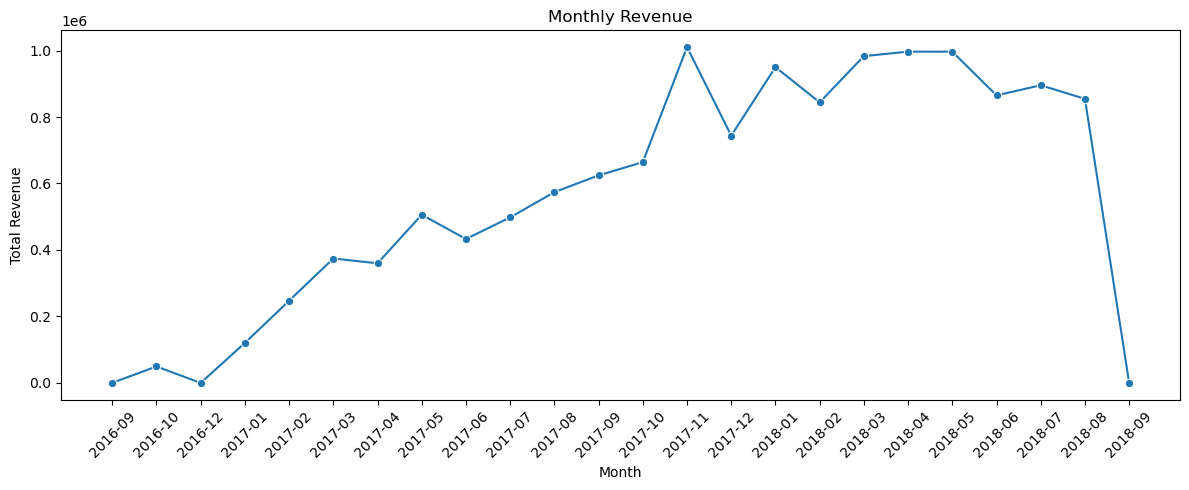

In [19]:
# =========================================================
# Chart 2: Monthly Revenue
# =========================================================

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_summary,
    x='YearMonth',
    y='TotalRevenue',
    marker='o'
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# =========================================================
# Highest revenue month
# =========================================================

best_revenue_month = monthly_summary.loc[
    monthly_summary['TotalRevenue'].idxmax()
]

print(
    "Highest Revenue Month:",
    best_revenue_month['YearMonth']
)

print(
    "Revenue:",
    best_revenue_month['TotalRevenue']
)

print(
    "Orders:",
    best_revenue_month['TotalOrders']
)

print(
    "AOV:",
    best_revenue_month['AverageOrderValue']
)

Highest Revenue Month: 2017-11
Revenue: 1010271.37
Orders: 7451
AOV: 135.59


In [ ]:
## Monthly Revenue and Order Insights

The monthly analysis compares order volume, total revenue, and average order value over time.
The peak revenue month can be identified from the monthly summary, while the order trend shows how overall customer activity changed throughout the dataset period.

In [22]:
# =========================================================
# P11: Payment & Review EDA
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Load datasets
# ---------------------------------------------------------

payments = pd.read_csv(
    "../../data/raw/olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    "../../data/raw/olist_order_reviews_dataset.csv"
)

print("Payments shape:", payments.shape)
print("Reviews shape:", reviews.shape)

Payments shape: (103886, 5)
Reviews shape: (99224, 7)


In [23]:
# =========================================================
# Payment Method Analysis
# =========================================================

payment_summary = (
    payments
    .groupby('payment_type')
    .agg(
        TotalOrders=('order_id', 'nunique'),
        TotalPaymentValue=('payment_value', 'sum'),
        AveragePaymentValue=('payment_value', 'mean')
    )
    .reset_index()
)

# Round values
payment_summary['TotalPaymentValue'] = (
    payment_summary['TotalPaymentValue'].round(2)
)

payment_summary['AveragePaymentValue'] = (
    payment_summary['AveragePaymentValue'].round(2)
)

# Sort by payment value
payment_summary = payment_summary.sort_values(
    'TotalPaymentValue',
    ascending=False
)

payment_summary

,payment_type,TotalOrders,TotalPaymentValue,AveragePaymentValue
1,credit_card,76505,12542084.19,163.32
0,boleto,19784,2869361.27,145.03
4,voucher,3866,379436.87,65.70
2,debit_card,1528,217989.79,142.57
3,not_defined,3,0.00,0.00


In [24]:
# =========================================================
# Payment Type Revenue Share
# =========================================================

total_payment_value = payment_summary[
    'TotalPaymentValue'
].sum()

payment_summary['PaymentSharePercent'] = (
    payment_summary['TotalPaymentValue'] * 100
    / total_payment_value
).round(2)

payment_summary

,payment_type,TotalOrders,TotalPaymentValue,AveragePaymentValue,PaymentSharePercent
1,credit_card,76505,12542084.19,163.32,78.34
0,boleto,19784,2869361.27,145.03,17.92
4,voucher,3866,379436.87,65.70,2.37
2,debit_card,1528,217989.79,142.57,1.36
3,not_defined,3,0.00,0.00,0.00


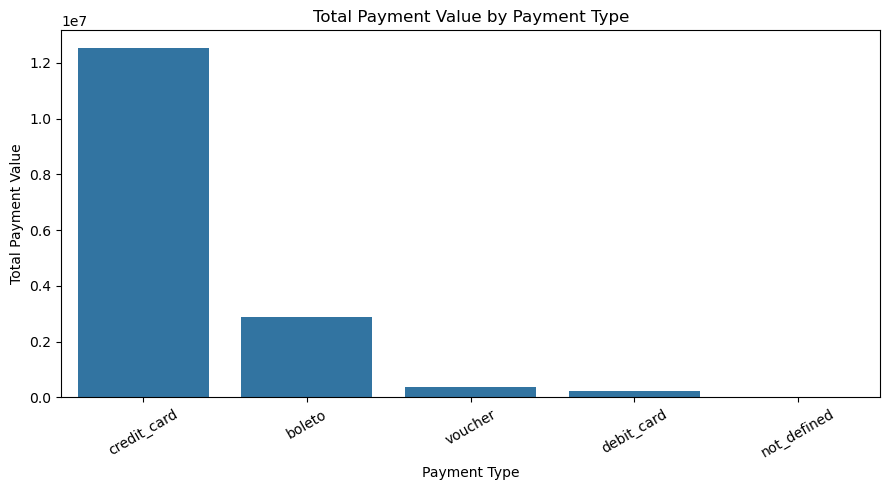

In [25]:
# =========================================================
# Payment Value by Payment Type
# =========================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_summary,
    x='payment_type',
    y='TotalPaymentValue'
)

plt.title('Total Payment Value by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Total Payment Value')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


In [26]:
# =========================================================
# Review Score Analysis
# =========================================================

review_summary = (
    reviews['review_score']
    .value_counts()
    .sort_index()
    .reset_index()
)

review_summary.columns = [
    'ReviewScore',
    'TotalReviews'
]

review_summary['ReviewPercentage'] = (
    review_summary['TotalReviews'] * 100
    / review_summary['TotalReviews'].sum()
).round(2)

review_summary

,ReviewScore,TotalReviews,ReviewPercentage
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


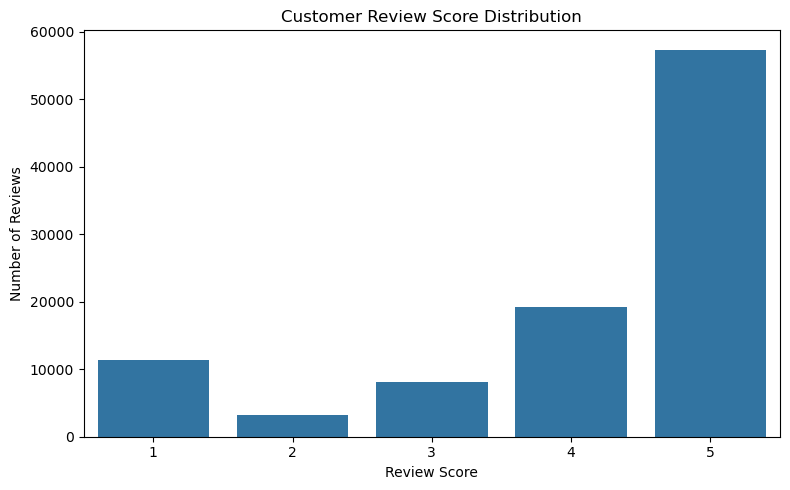

In [27]:
# =========================================================
# Review Score Distribution
# =========================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=review_summary,
    x='ReviewScore',
    y='TotalReviews'
)

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

In [28]:
# =========================================================
# Review Category Summary
# =========================================================

reviews['ReviewCategory'] = np.select(
    [
        reviews['review_score'].isin([4, 5]),
        reviews['review_score'].eq(3),
        reviews['review_score'].isin([1, 2])
    ],
    [
        'Positive',
        'Neutral',
        'Negative'
    ],
    default='Unknown'
)

review_category_summary = (
    reviews['ReviewCategory']
    .value_counts()
    .reset_index()
)

review_category_summary.columns = [
    'ReviewCategory',
    'TotalReviews'
]

review_category_summary['ReviewPercentage'] = (
    review_category_summary['TotalReviews'] * 100
    / review_category_summary['TotalReviews'].sum()
).round(2)

review_category_summary

,ReviewCategory,TotalReviews,ReviewPercentage
0,Positive,76470,77.07
1,Negative,14575,14.69
2,Neutral,8179,8.24


In [ ]:
## Payment and Review Insights

- Identify the payment method with the highest total payment value.
- Identify the most common review score.
- Compare positive, neutral, and negative reviews.
- Explain what the review distribution suggests about overall customer satisfaction.

In [11]:
# =========================================================
# P12: Delivery Performance EDA
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load orders dataset
orders = pd.read_csv(
    "../../data/raw/olist_orders_dataset.csv"
)

print("Orders:", orders.shape)

# ---------------------------------------------------------
# 1. Convert date columns
# ---------------------------------------------------------

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'],
    errors='coerce'
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date'],
    errors='coerce'
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date'],
    errors='coerce'
)

# ---------------------------------------------------------
# 2. Extract Year and Month
# ---------------------------------------------------------

orders['Year'] = (
    orders['order_purchase_timestamp'].dt.year
)

orders['Month'] = (
    orders['order_purchase_timestamp'].dt.month
)

orders.head()

Orders: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Year,Month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2


In [12]:
# =========================================================
# Create delivery-level metrics
# =========================================================

# Keep only orders that were actually delivered
delivered_orders = orders[
    orders['order_delivered_customer_date'].notna()
].copy()

# Delivery time in days
delivered_orders['DeliveryDays'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

# Late delivery flag
delivered_orders['LateOrder'] = (
    delivered_orders['order_delivered_customer_date']
    >
    delivered_orders['order_estimated_delivery_date']
)

# Year and month based on purchase date
delivered_orders['Year'] = (
    delivered_orders['order_purchase_timestamp'].dt.year
)

delivered_orders['Month'] = (
    delivered_orders['order_purchase_timestamp'].dt.month
)

delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Year,Month,DeliveryDays,LateOrder
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,8.436574,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,13.782037,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,9.394213,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,13.208750,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,2.873877,False


In [13]:
# =========================================================
# Monthly Delivery Performance Summary
# =========================================================

monthly_delivery = (
    delivered_orders
    .groupby(['Year', 'Month'])
    .agg(
        TotalDeliveredOrders=('order_id', 'nunique'),
        LateOrders=('LateOrder', 'sum'),
        AverageDeliveryDays=('DeliveryDays', 'mean')
    )
    .reset_index()
)

# Late delivery percentage
monthly_delivery['LateDeliveryRatePercent'] = (
    monthly_delivery['LateOrders'] * 100.0
    / monthly_delivery['TotalDeliveredOrders']
)

# Round values
monthly_delivery['AverageDeliveryDays'] = (
    monthly_delivery['AverageDeliveryDays'].round(2)
)

monthly_delivery['LateDeliveryRatePercent'] = (
    monthly_delivery['LateDeliveryRatePercent'].round(2)
)

# Sort chronologically
monthly_delivery = monthly_delivery.sort_values(
    ['Year', 'Month']
).reset_index(drop=True)

# Create readable Year-Month label
monthly_delivery['YearMonth'] = (
    monthly_delivery['Year'].astype(str)
    + '-'
    + monthly_delivery['Month'].astype(str).str.zfill(2)
)

monthly_delivery

,Year,Month,TotalDeliveredOrders,LateOrders,AverageDeliveryDays,LateDeliveryRatePercent,YearMonth
0,2016,9,1,1,54.81,100.00,2016-09
1,2016,10,270,3,19.58,1.11,2016-10
2,2016,12,1,0,4.69,0.00,2016-12
3,2017,1,750,23,12.65,3.07,2017-01
4,2017,2,1653,53,13.17,3.21,2017-02
5,2017,3,2546,142,12.95,5.58,2017-03
6,2017,4,2303,181,14.92,7.86,2017-04
7,2017,5,3545,128,11.32,3.61,2017-05
8,2017,6,3135,121,12.01,3.86,2017-06
9,2017,7,3872,133,11.59,3.43,2017-07


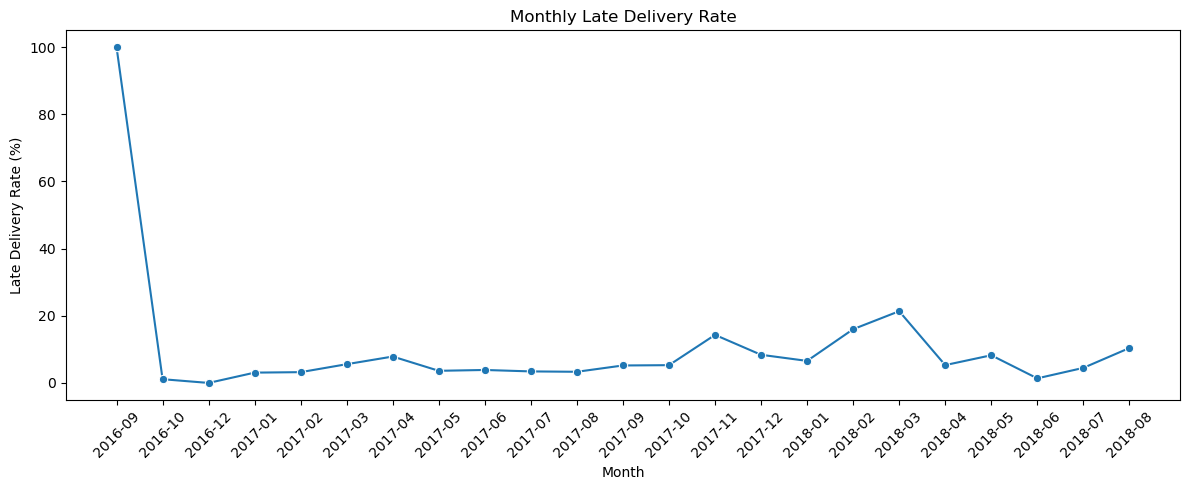

In [14]:
# =========================================================
# Chart 1: Monthly Late Delivery Rate
# =========================================================

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_delivery,
    x='YearMonth',
    y='LateDeliveryRatePercent',
    marker='o'
)

plt.title('Monthly Late Delivery Rate')
plt.xlabel('Month')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

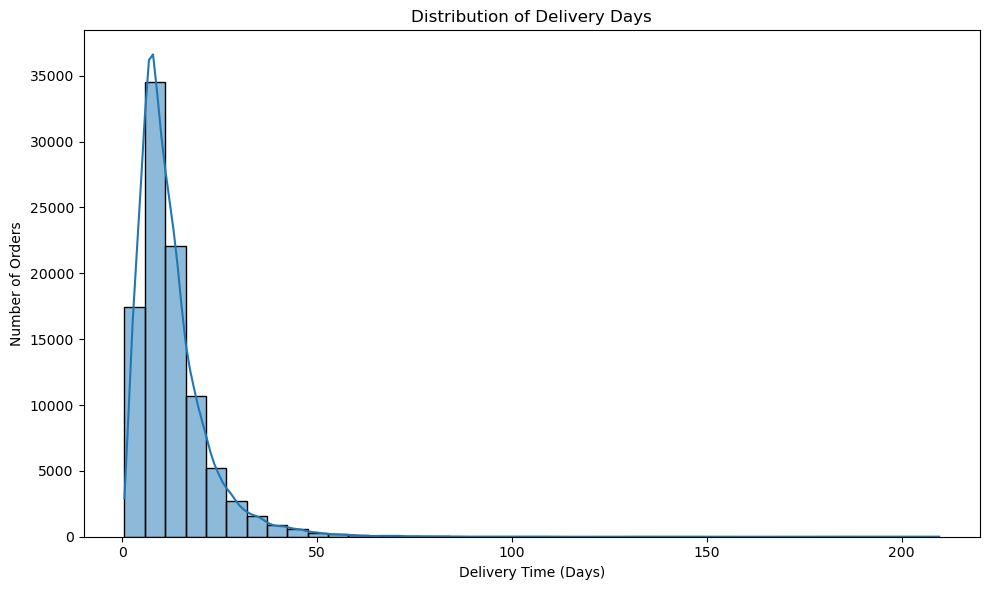

In [15]:
# =========================================================
# Chart 2: Distribution of Delivery Days
# =========================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=delivered_orders,
    x='DeliveryDays',
    bins=40,
    kde=True
)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [38]:
# =========================================================
# Overall Delivery Statistics
# =========================================================

maximum_delivery_days = delivered_orders['DeliveryDays'].max()
average_delivery_days = delivered_orders['DeliveryDays'].mean()
median_delivery_days = delivered_orders['DeliveryDays'].median()

print(
    "Maximum Delivery Days:",
    round(maximum_delivery_days, 2)
)

print(
    "Average Delivery Days:",
    round(average_delivery_days, 2)
)

print(
    "Median Delivery Days:",
    round(median_delivery_days, 2)
)

Maximum Delivery Days: 209.63
Average Delivery Days: 12.56
Median Delivery Days: 10.22


In [39]:
# =========================================================
# Identify unusually long delivery times
# =========================================================

long_delivery_threshold = 30

long_deliveries = delivered_orders[
    delivered_orders['DeliveryDays'] > long_delivery_threshold
].copy()

print(
    "Orders delivered in more than",
    long_delivery_threshold,
    "days:",
    len(long_deliveries)
)

print(
    "Percentage of delivered orders:",
    round(
        len(long_deliveries) * 100
        / len(delivered_orders),
        2
    ),
    "%"
)

Orders delivered in more than 30 days: 4553
Percentage of delivered orders: 4.72 %


In [40]:
# =========================================================
# Months with highest late-delivery rates
# =========================================================

worst_months = monthly_delivery.sort_values(
    'LateDeliveryRatePercent',
    ascending=False
)

worst_months[
    [
        'YearMonth',
        'TotalDeliveredOrders',
        'LateOrders',
        'LateDeliveryRatePercent',
        'AverageDeliveryDays'
    ]
].head(10)

,YearMonth,TotalDeliveredOrders,LateOrders,LateDeliveryRatePercent,AverageDeliveryDays
0,2016-09,1,1,100.00,54.81
17,2018-03,7003,1496,21.36,16.30
16,2018-02,6556,1049,16.00,16.95
13,2017-11,7288,1043,14.31,15.16
22,2018-08,6351,660,10.39,7.73
14,2017-12,5513,462,8.38,15.39
19,2018-05,6749,556,8.24,11.42
6,2017-04,2303,181,7.86,14.92
15,2018-01,7069,464,6.56,14.08
5,2017-03,2546,142,5.58,12.95


In [41]:
# =========================================================
# Best and Worst Delivery Months
# =========================================================

best_month = monthly_delivery.loc[
    monthly_delivery['LateDeliveryRatePercent'].idxmin()
]

worst_month = monthly_delivery.loc[
    monthly_delivery['LateDeliveryRatePercent'].idxmax()
]

print("Best Month for Delivery Performance:")
print(best_month)

print("\nWorst Month for Delivery Performance:")
print(worst_month)

Best Month for Delivery Performance:
Year                          2016
Month                           12
TotalDeliveredOrders             1
LateOrders                       0
AverageDeliveryDays           4.69
LateDeliveryRatePercent        0.0
YearMonth                  2016-12
Name: 2, dtype: object

Worst Month for Delivery Performance:
Year                          2016
Month                            9
TotalDeliveredOrders             1
LateOrders                       1
AverageDeliveryDays          54.81
LateDeliveryRatePercent      100.0
YearMonth                  2016-09
Name: 0, dtype: object


In [42]:
# =========================================================
# Final P12 Summary
# =========================================================

delivery_summary = pd.DataFrame({
    'Metric': [
        'Total Delivered Orders',
        'Total Late Orders',
        'Overall Late Delivery Rate',
        'Average Delivery Days',
        'Median Delivery Days',
        'Maximum Delivery Days'
    ],
    'Value': [
        len(delivered_orders),
        delivered_orders['LateOrder'].sum(),
        round(
            delivered_orders['LateOrder'].mean() * 100,
            2
        ),
        round(average_delivery_days, 2),
        round(median_delivery_days, 2),
        round(maximum_delivery_days, 2)
    ]
})

delivery_summary

,Metric,Value
0,Total Delivered Orders,96476.00
1,Total Late Orders,7827.00
2,Overall Late Delivery Rate,8.11
3,Average Delivery Days,12.56
4,Median Delivery Days,10.22
5,Maximum Delivery Days,209.63


In [ ]:
## Delivery Performance Insights

The delivery analysis shows how delivery speed and late-delivery rates changed over time.

The monthly late-delivery chart highlights the months with the strongest delivery performance and the months with the highest proportion of late orders.

The difference between the average and median delivery time helps identify whether a small number of unusually long deliveries are affecting the overall average.

Long-delivery orders should be investigated further because they may indicate operational or logistics problems.

In [43]:
# =========================================================
# P13: Product & Seller Performance EDA
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

products = pd.read_csv(
    "../../data/raw/olist_products_dataset.csv"
)

order_items = pd.read_csv(
    "../../data/raw/olist_order_items_dataset.csv"
)

sellers = pd.read_csv(
    "../../data/raw/olist_sellers_dataset.csv"
)

# Translation file is TAB-separated
translation = pd.read_csv(
    "../../data/raw/product_category_name_translation.csv",
    sep="\t"
)

print("Products:", products.shape)
print("Order Items:", order_items.shape)
print("Sellers:", sellers.shape)
print("Translation:", translation.shape)

Products: (32951, 9)
Order Items: (112650, 7)
Sellers: (3095, 4)
Translation: (71, 2)


In [44]:
# =========================================================
# Part A: Product Category Performance
# =========================================================

# Join order items with products
category_data = order_items[
    ['product_id', 'price']
].merge(
    products[
        ['product_id', 'product_category_name']
    ],
    on='product_id',
    how='left'
)

# Join category translation
category_data = category_data.merge(
    translation[
        [
            'product_category_name',
            'product_category_name_english'
        ]
    ],
    on='product_category_name',
    how='left'
)

# Create readable category name
category_data['ProductCategory'] = (
    category_data['product_category_name_english']
    .fillna(category_data['product_category_name'])
    .fillna('Unknown')
)

# Calculate category metrics
category_summary = (
    category_data
    .groupby('ProductCategory')
    .agg(
        TotalItemsSold=('product_id', 'count'),
        TotalRevenue=('price', 'sum'),
        AverageSellingPrice=('price', 'mean')
    )
    .reset_index()
)

category_summary['TotalRevenue'] = (
    category_summary['TotalRevenue'].round(2)
)

category_summary['AverageSellingPrice'] = (
    category_summary['AverageSellingPrice'].round(2)
)

category_summary = category_summary.sort_values(
    'TotalRevenue',
    ascending=False
)

category_summary.head(10)

,ProductCategory,TotalItemsSold,TotalRevenue,AverageSellingPrice
44,health_beauty,9670,1258681.34,130.16
73,watches_gifts,5991,1205005.68,201.14
8,bed_bath_table,11115,1036988.68,93.30
68,sports_leisure,8641,988048.97,114.34
16,computers_accessories,7827,911954.32,116.51
40,furniture_decor,8334,729762.49,87.56
21,cool_stuff,3796,635290.85,167.36
50,housewares,6964,632248.66,90.79
6,auto,4235,592720.11,139.96
43,garden_tools,4347,485256.46,111.63


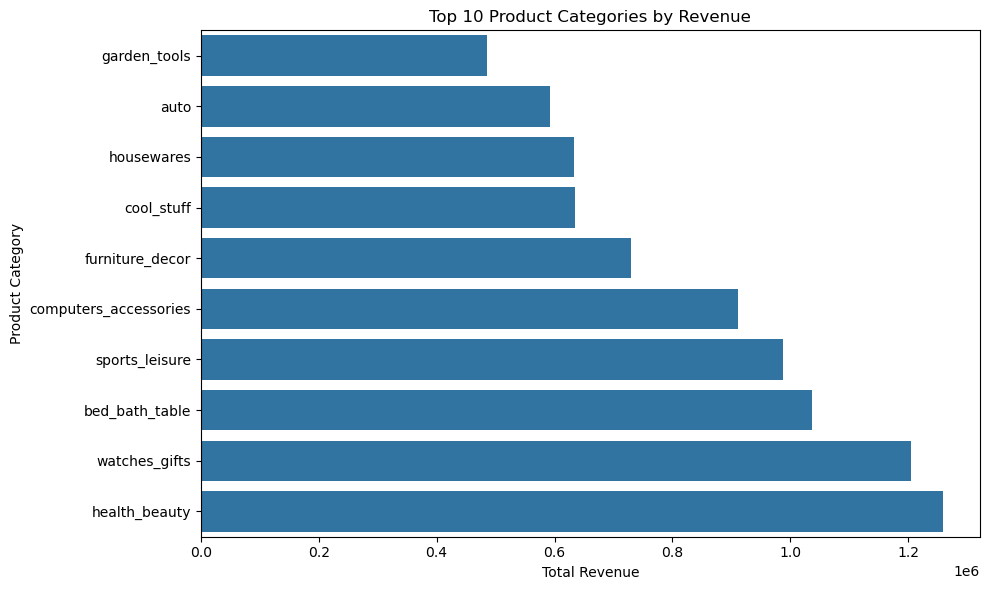

In [45]:
# =========================================================
# Top 10 Product Categories by Revenue
# =========================================================

top10_categories = (
    category_summary
    .head(10)
    .sort_values('TotalRevenue', ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_categories,
    x='TotalRevenue',
    y='ProductCategory'
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

In [46]:
# =========================================================
# Top 10 Category Revenue Share
# =========================================================

top10_category_revenue = (
    category_summary.head(10)['TotalRevenue'].sum()
)

total_category_revenue = (
    category_summary['TotalRevenue'].sum()
)

top10_category_share = (
    top10_category_revenue * 100
    / total_category_revenue
)

print(
    "Top 10 Category Revenue Share:",
    round(top10_category_share, 2),
    "%"
)

Top 10 Category Revenue Share: 62.36 %


In [47]:
# =========================================================
# Part B: Seller Performance
# =========================================================

seller_data = order_items[
    ['seller_id', 'price']
].merge(
    sellers[
        ['seller_id', 'seller_city', 'seller_state']
    ],
    on='seller_id',
    how='left'
)

seller_summary = (
    seller_data
    .groupby(
        [
            'seller_id',
            'seller_city',
            'seller_state'
        ]
    )
    .agg(
        TotalItemsSold=('seller_id', 'count'),
        TotalRevenue=('price', 'sum'),
        AverageItemPrice=('price', 'mean')
    )
    .reset_index()
)

seller_summary['TotalRevenue'] = (
    seller_summary['TotalRevenue'].round(2)
)

seller_summary['AverageItemPrice'] = (
    seller_summary['AverageItemPrice'].round(2)
)

seller_summary = seller_summary.sort_values(
    'TotalRevenue',
    ascending=False
)

seller_summary.head(10)

,seller_id,seller_city,seller_state,TotalItemsSold,TotalRevenue,AverageItemPrice
857,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1156,229472.63,198.51
1013,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,410,222776.05,543.36
881,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1987,200472.92,100.89
3024,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,586,194042.03,331.13
1535,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,1364,187923.89,137.77
1560,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,340,176431.87,518.92
2643,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1551,160236.57,103.31
1505,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1171,141745.53,121.05
192,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,1428,138968.55,97.32
1824,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,1499,135171.70,90.17


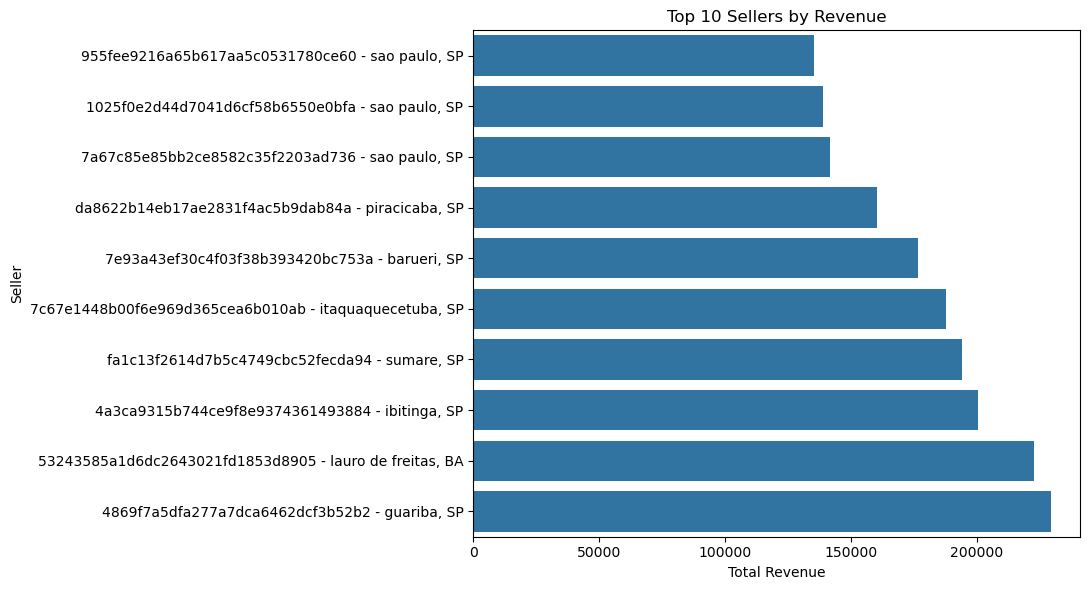

In [48]:
# =========================================================
# Top 10 Sellers by Revenue
# =========================================================

top10_sellers = (
    seller_summary
    .head(10)
    .copy()
)

top10_sellers['SellerLabel'] = (
    top10_sellers['seller_id']
    + ' - '
    + top10_sellers['seller_city']
    + ', '
    + top10_sellers['seller_state']
)

plot_sellers = (
    top10_sellers
    .sort_values('TotalRevenue', ascending=True)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_sellers,
    x='TotalRevenue',
    y='SellerLabel'
)

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Seller')

plt.tight_layout()
plt.show()

In [49]:
# =========================================================
# Top 10 Seller Revenue Share
# =========================================================

top10_seller_revenue = (
    seller_summary.head(10)['TotalRevenue'].sum()
)

total_seller_revenue = (
    seller_summary['TotalRevenue'].sum()
)

top10_seller_share = (
    top10_seller_revenue * 100
    / total_seller_revenue
)

print(
    "Top 10 Seller Revenue Share:",
    round(top10_seller_share, 2),
    "%"
)

Top 10 Seller Revenue Share: 13.15 %


In [50]:
# =========================================================
# Product & Seller Comparison
# =========================================================

comparison = pd.DataFrame({
    'Metric': [
        'Total Category Revenue',
        'Top 10 Category Revenue',
        'Top 10 Category Revenue Share',
        'Total Seller Revenue',
        'Top 10 Seller Revenue',
        'Top 10 Seller Revenue Share'
    ],
    'Value': [
        round(total_category_revenue, 2),
        round(top10_category_revenue, 2),
        round(top10_category_share, 2),
        round(total_seller_revenue, 2),
        round(top10_seller_revenue, 2),
        round(top10_seller_share, 2)
    ]
})

comparison

,Metric,Value
0,Total Category Revenue,13591643.70
1,Top 10 Category Revenue,8475957.56
2,Top 10 Category Revenue Share,62.36
3,Total Seller Revenue,13591643.70
4,Top 10 Seller Revenue,1787241.74
5,Top 10 Seller Revenue Share,13.15


In [ ]:
## Product & Seller Insights

The analysis identifies the product categories contributing the greatest share of revenue and highlights whether category revenue is concentrated in a small number of categories.

The seller analysis shows which sellers generate the highest revenue and whether seller revenue is similarly concentrated.

The revenue-share metrics provide a useful indication of sales concentration and can help identify categories and sellers that have a disproportionate impact on overall business performance.

In [10]:
excel_monthly_data = monthly_summary[
    [
        'Year',
        'Month',
        'TotalOrders',
        'TotalRevenue',
        'AverageOrderValue'
    ]
]

In [11]:
excel_monthly_data

,Year,Month,TotalOrders,TotalRevenue,AverageOrderValue
0,2016,9,3,267.36,89.12
1,2016,10,308,49507.66,160.74
2,2016,12,1,10.90,10.90
3,2017,1,789,120312.87,152.49
4,2017,2,1733,247303.02,142.70
5,2017,3,2641,374344.30,141.74
6,2017,4,2391,359927.23,150.53
7,2017,5,3660,506071.14,138.27
8,2017,6,3217,433038.60,134.61
9,2017,7,3969,498031.48,125.48


In [12]:
excel_monthly_data.to_clipboard(
    index=False
)

In [9]:
excel_product_data = category_summary[
    [
        'ProductCategory',
        'TotalItemsSold',
        'TotalRevenue',
        'AverageSellingPrice'
    ]
]

excel_product_data

,ProductCategory,TotalItemsSold,TotalRevenue,AverageSellingPrice
44,health_beauty,9670,1258681.34,130.16
73,watches_gifts,5991,1205005.68,201.14
8,bed_bath_table,11115,1036988.68,93.30
68,sports_leisure,8641,988048.97,114.34
16,computers_accessories,7827,911954.32,116.51
...,...,...,...,...
36,flowers,33,1110.04,33.64
47,home_comfort_2,30,760.27,25.34
12,cds_dvds_musicals,14,730.00,52.14
30,fashion_childrens_clothes,8,569.85,71.23


In [10]:
excel_product_data.to_clipboard(index=False)

In [16]:
excel_delivery_data = monthly_delivery[
    [
        'Year',
        'Month',
        'TotalDeliveredOrders',
        'LateOrders',
        'LateDeliveryRatePercent',
        'AverageDeliveryDays'
    ]
]

excel_delivery_data.to_clipboard(index=False)